# Plot Ice Mask on Fedchenko Glacier

In [4]:
import sys
#sys.path.insert(1, '/home/santolam/MyPythonLibrary/MAR-RECAP/libmar/')
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
#sys.path.insert(1, '/Users/santolam/Documents/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [5]:
# sourceDataM='/bettik/PROJECTS/pr-regional-climate/santolam/MARout/'
dsGrid=xr.open_dataset('/home/amoryc/NST.2000.01.01.00.GRp.nc')
dsSH=dsGrid['SH']
ICE=dsGrid['ICE']
LONS=dsGrid.LON.values
LATS=dsGrid.LAT.values
dsSH=dsGrid.SH
dsICE=dsGrid.ICE

In [6]:
ds_ICE100= xr.where(ICE.values== 100,ICE, np.nan)
ds_ICE0= xr.where(ICE.values== 0,ICE, np.nan)

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

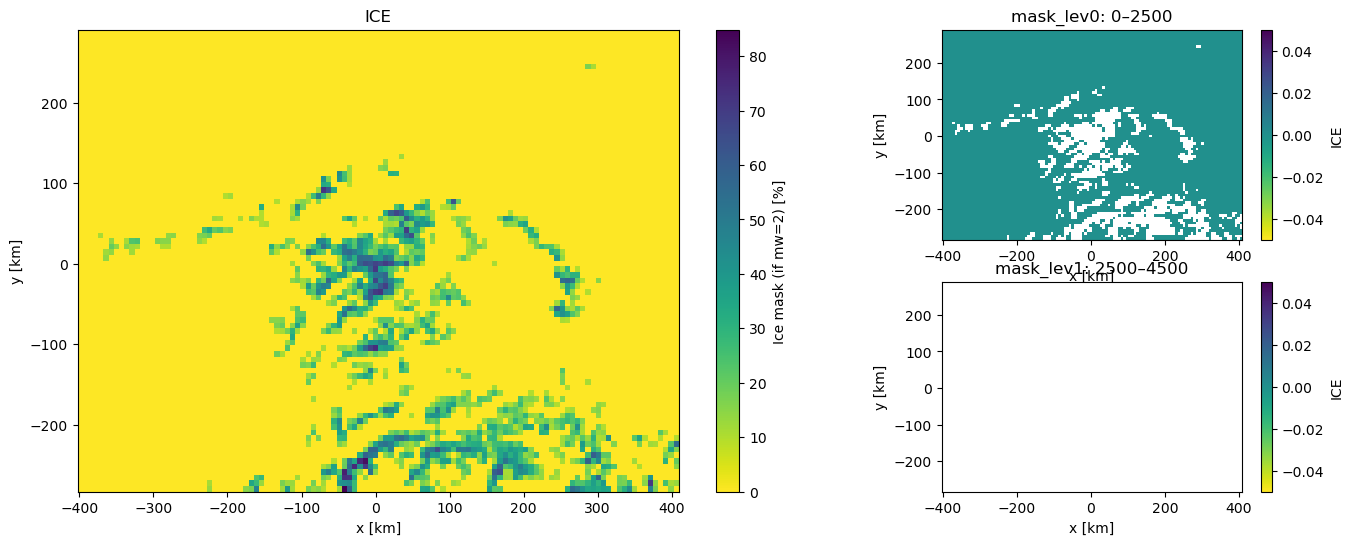

In [7]:
fig = plt.figure(figsize=(16, 6))
gs = gridspec.GridSpec(2, 2, width_ratios=[2, 1])  # 2 rows, 2 columns

# Large plot on the left (occupies both rows of first column)
ax_main = fig.add_subplot(gs[:, 0])
ICE.plot(cmap='viridis_r', ax=ax_main)
ax_main.set_title("ICE")

# Two smaller plots on the right column
ax1 = fig.add_subplot(gs[0, 1])
ds_ICE0.plot(cmap='viridis_r',ax=ax1)
ax1.set_title("mask_lev0: 0–2500")

ax2 = fig.add_subplot(gs[1, 1])
ds_ICE100.plot(cmap='viridis_r',ax=ax2)
ax2.set_title("mask_lev1: 2500–4500")

plt.tight_layout

/tmp/ipykernel_816002/14985568.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


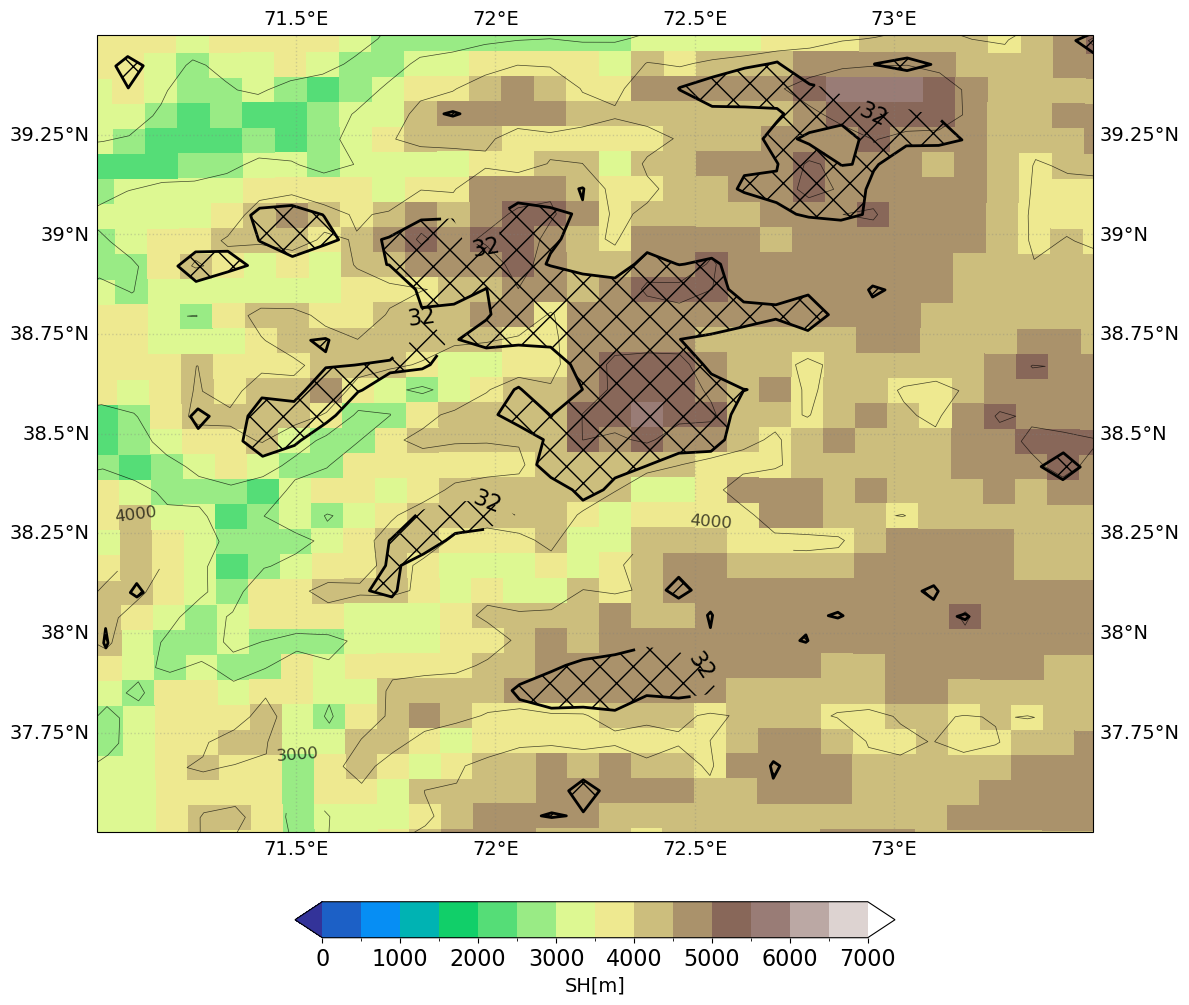

In [8]:
ice_level=32# % of ice on grid cell

clevs=np.arange(0,7500,500)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(LONS,LATS,dsSH,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

ICE1=ax.contourf(LONS, LATS,dsICE,
            levels=[10,ice_level,100],
            hatches=['','X','X'],
            colors="none",
            transform=ccrs.PlateCarree())

#    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)
SH1 = ax.contour(LONS, LATS, dsSH,
                             levels=[1000,2000,3000,4000,5000,6000,7000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(LONS, LATS, dsICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")
 
ax.set_extent([71, 73.5, 37.5, 39.5], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

plt.show()